In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#to remove warning
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [3]:
DDOS=pd.read_csv("..\CIC-IDS2017-Dataset\DDoS-Friday-no-metadata.parquet.csv")

In [4]:
print(DDOS.columns)

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Fla

In [5]:
DDOS.describe

<bound method NDFrame.describe of         Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0              6              3                  2                       0   
1              6            109                  1                       1   
2              6             52                  1                       1   
3              6             34                  1                       1   
4              6              3                  2                       0   
...          ...            ...                ...                     ...   
221259         6             61                  1                       1   
221260         6             72                  1                       1   
221261         6             75                  1                       1   
221262         6             48                  2                       0   
221263         6             68                  1                       1   

        Fwd Packets Length To

In [6]:
#checking for null values
null_check=DDOS.isnull().sum()
print(null_check)
null_checker=null_check.sum()
if null_checker == 0:
    print("There are no null values")
else:
    print("Null values present cleaning required")

Protocol                    0
Flow Duration               0
Total Fwd Packets           0
Total Backward Packets      0
Fwd Packets Length Total    0
                           ..
Idle Mean                   0
Idle Std                    0
Idle Max                    0
Idle Min                    0
Label                       0
Length: 78, dtype: int64
There are no null values


Data doesn't have any missing values


Step 3: Analyzing target class distributions...
Label
DDoS      128014
Benign     93250
Name: count, dtype: int64


C:\Users\admin\AppData\Local\Temp\ipykernel_28348\3863627128.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


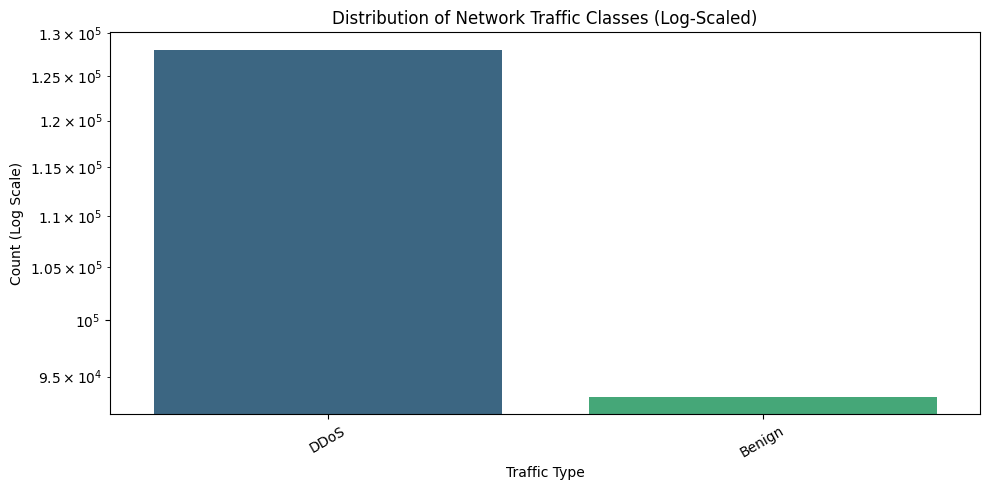

In [7]:
print("\nStep 3: Analyzing target class distributions...")
# Print numerical breakdown
print(DDOS['Label'].value_counts())

# Generate Log-Scaled Count Plot
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=DDOS, 
    x='Label', 
    order=DDOS['Label'].value_counts().index, 
    palette='viridis'
)
ax.set_yscale('log')  # Force log scale so minority DoS attacks are visible
plt.xticks(rotation=30)
plt.title('Distribution of Network Traffic Classes (Log-Scaled)')
plt.ylabel('Count (Log Scale)')
plt.xlabel('Traffic Type')
plt.tight_layout()
plt.show()

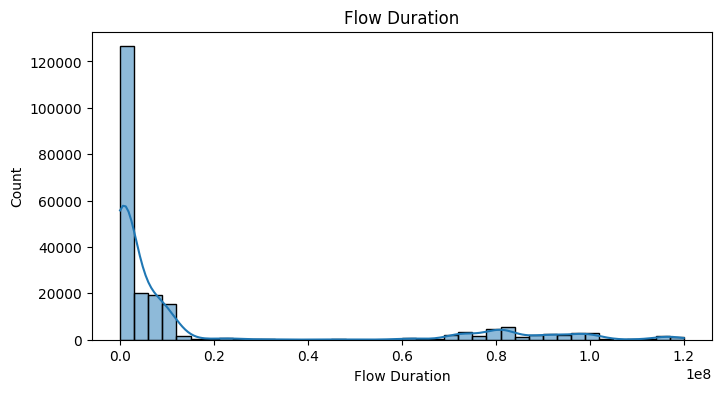

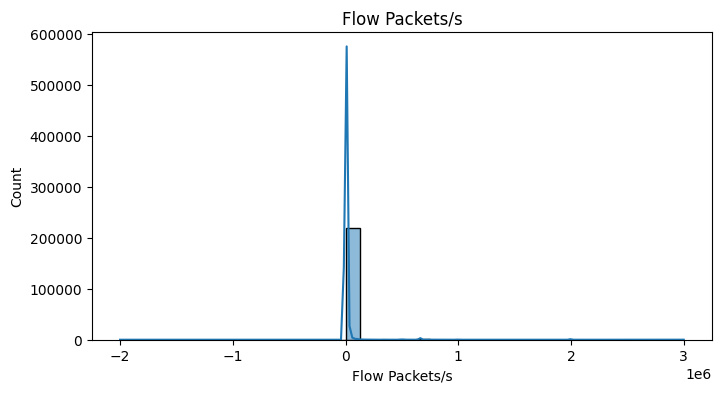

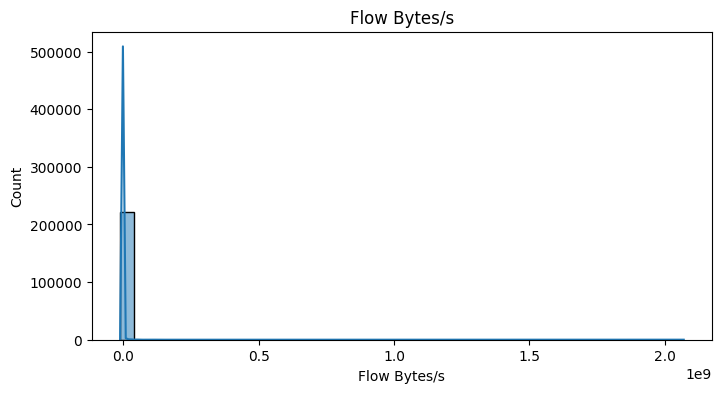

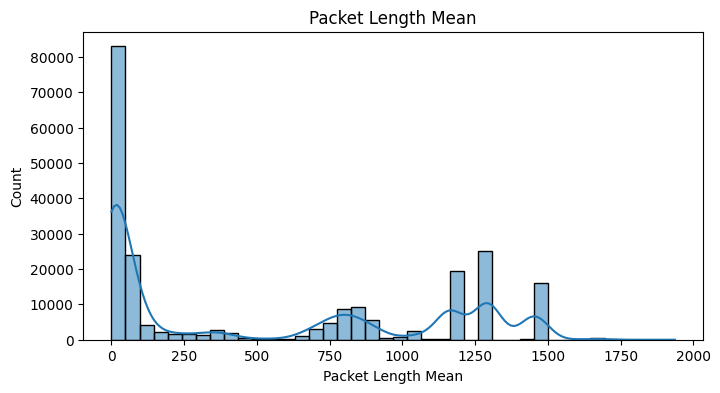

In [8]:
features=['Flow Duration','Flow Packets/s','Flow Bytes/s','Packet Length Mean']
for feature in features:
    plt.figure(figsize=(8,4))
    sns.histplot(DDOS[feature],bins=40,kde=True)
    plt.title(feature)
    plt.show()


Step 4: Plotting volumetric traffic spikes...


C:\Users\admin\AppData\Local\Temp\ipykernel_28348\3256865913.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=DDOS, x='Label', y='Flow Packets/s', palette='Set1')


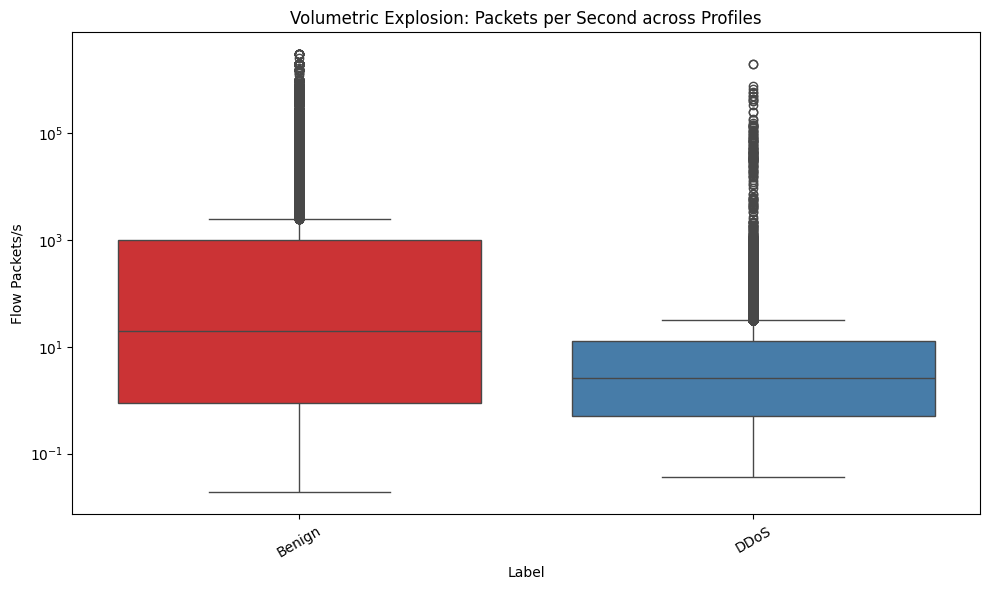

In [9]:
print("\nStep 4: Plotting volumetric traffic spikes...")

plt.figure(figsize=(10, 6))
# Using Flow Packets/s to capture raw traffic velocity
sns.boxplot(data=DDOS, x='Label', y='Flow Packets/s', palette='Set1')
plt.yscale('log')  # High-volume floods require log-scaling to visualize properly
plt.xticks(rotation=30)
plt.title('Volumetric Explosion: Packets per Second across Profiles')
plt.tight_layout()
plt.show()


Step 5: Visualizing arrival pacing variations...


C:\Users\admin\AppData\Local\Temp\ipykernel_28348\1692652764.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=DDOS, x='Label', y='Fwd IAT Min', palette='coolwarm')


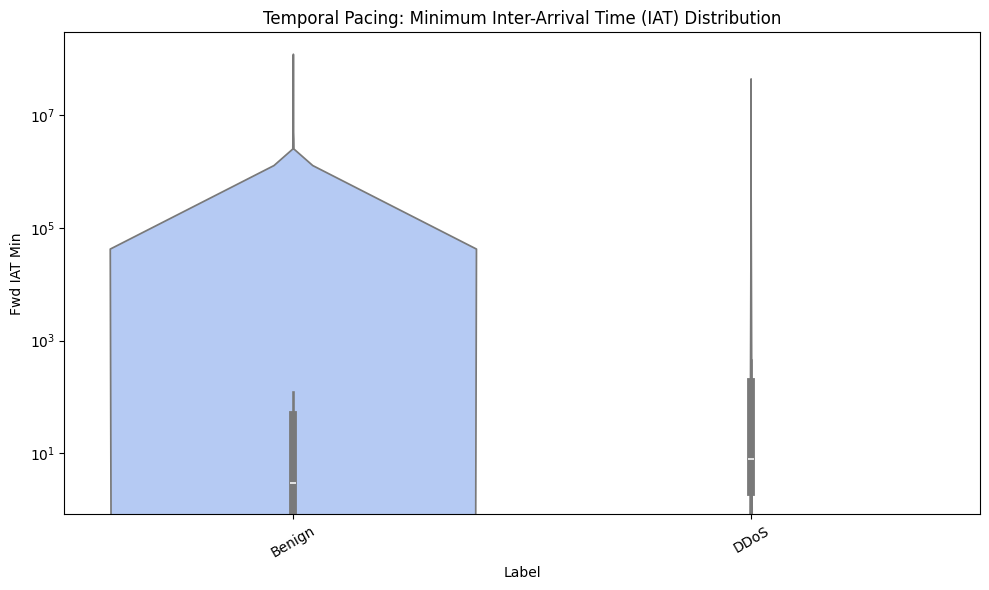

In [10]:
print("\nStep 5: Visualizing arrival pacing variations...")

plt.figure(figsize=(10, 6))
# Using Forward Inter-Arrival Time Minimum to catch scripted zero-delay pacing
sns.violinplot(data=DDOS, x='Label', y='Fwd IAT Min', palette='coolwarm')
plt.yscale('log')
plt.xticks(rotation=30)
plt.title('Temporal Pacing: Minimum Inter-Arrival Time (IAT) Distribution')
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_28348\1091963818.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


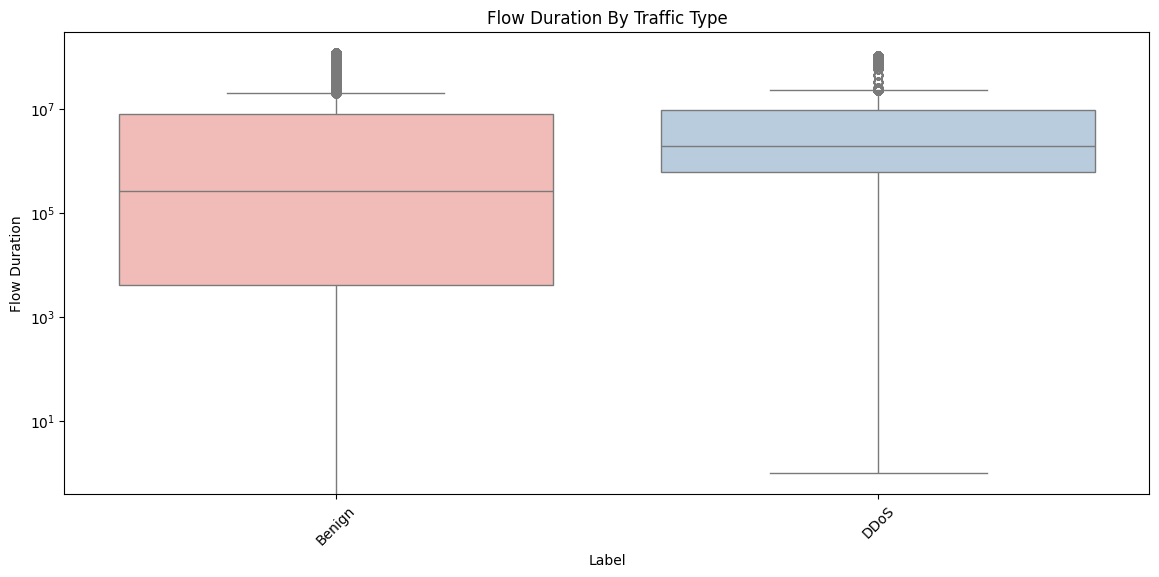

In [11]:
#Flow Duration Analysis(Boxplot)
plt.figure(figsize=(14,6))
sns.boxplot(
    data=DDOS,
    x='Label',
    y='Flow Duration',
    palette='Pastel1'
)
plt.yscale('log')
plt.xticks(rotation=45)
plt.title("Flow Duration By Traffic Type")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_28348\552655452.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


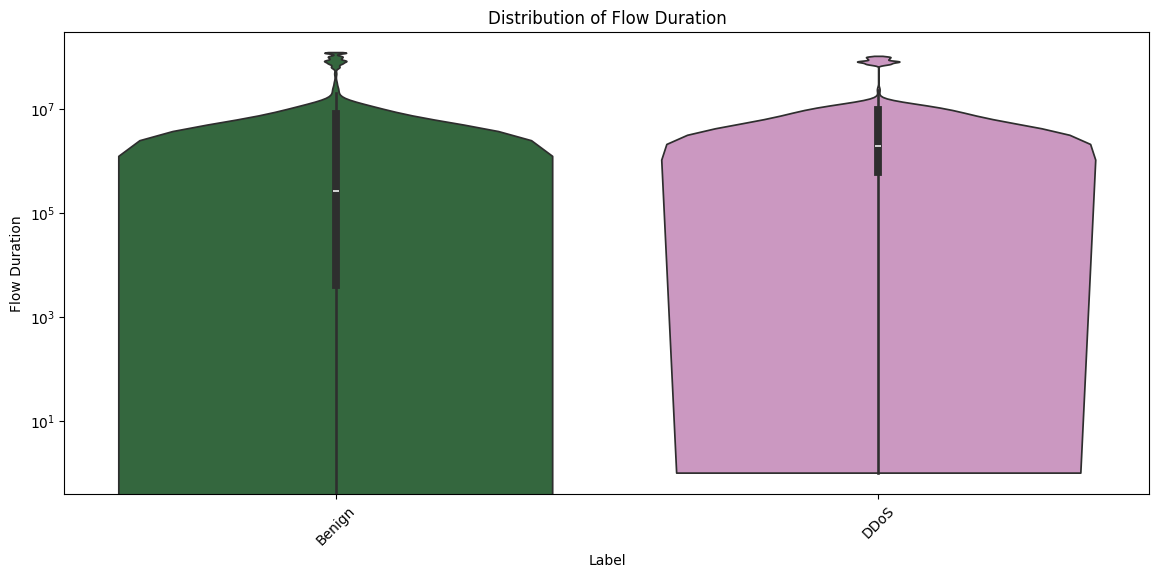

In [12]:
#Violin Plot
plt.figure(figsize=(14,6))
sns.violinplot(
    data=DDOS,
    x='Label',
    y='Flow Duration',
    palette='cubehelix',
    cut=0
)
plt.yscale('log')
plt.xticks(rotation=45)
plt.title("Distribution of Flow Duration")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_28348\2154758832.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


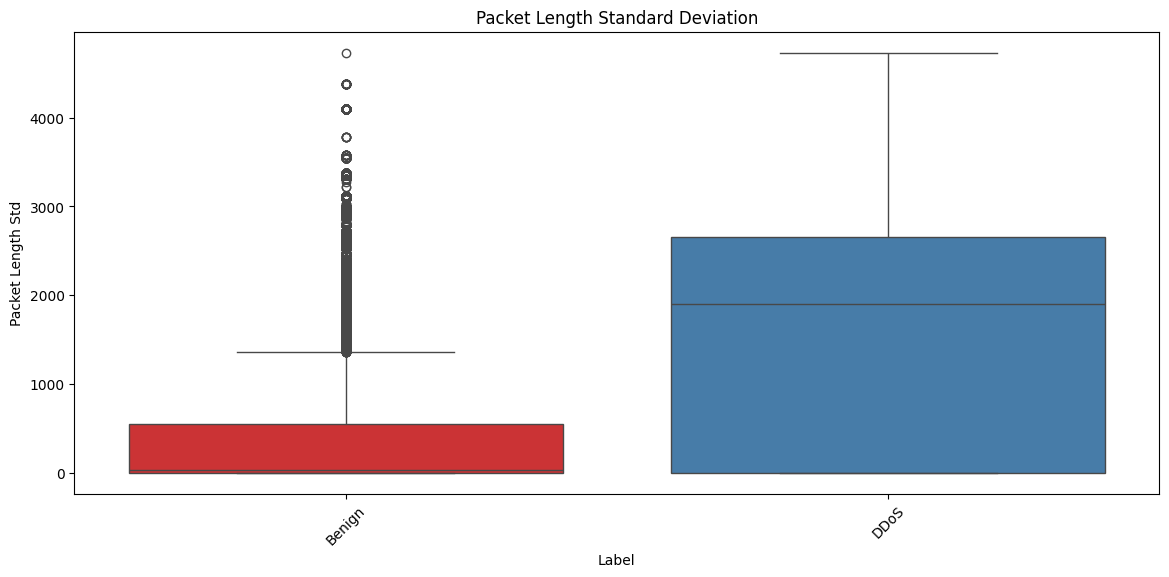

In [13]:
#PAcket Structure Analysis(Boxplot)
plt.figure(figsize=(14,6))
sns.boxplot(
    data=DDOS,
    x='Label',
    y='Packet Length Std',
    palette='Set1'
)
plt.xticks(rotation=45)
plt.title("Packet Length Standard Deviation")
plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_28348\3892189018.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


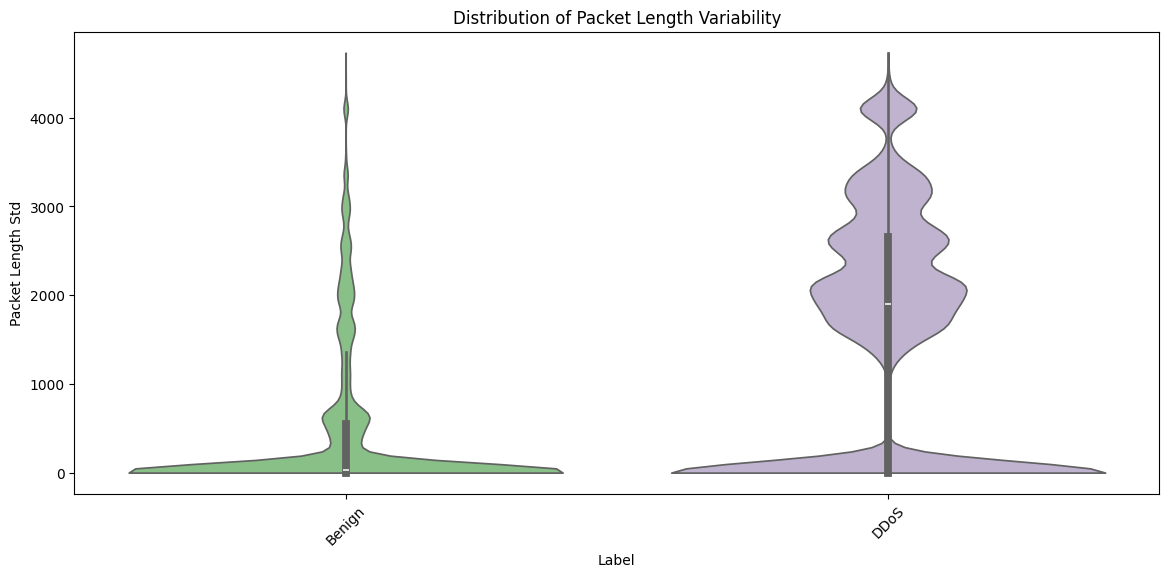

In [14]:
#Violin Plot
plt.figure(figsize=(14,6))
sns.violinplot(
    data=DDOS,
    x="Label",
    y="Packet Length Std",
    palette='Accent',
    cut=0
)
plt.xticks(rotation=45)
plt.title("Distribution of Packet Length Variability")
plt.show()


Step 6: Visualizing packet structure variances...


C:\Users\admin\AppData\Local\Temp\ipykernel_28348\3640786894.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=DDOS, x='Label', y='Fwd Packet Length Max', palette='Set2')


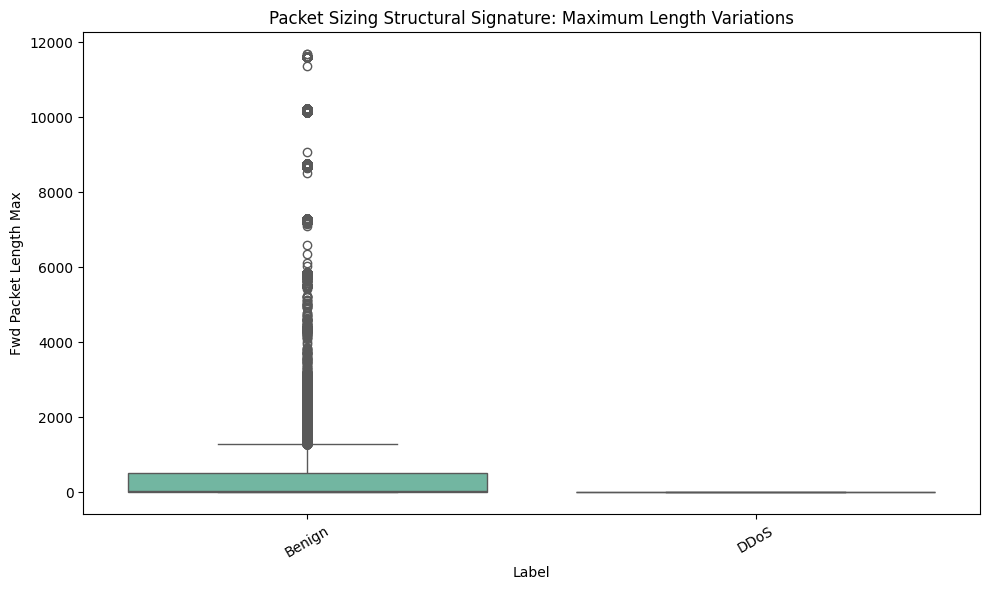

In [15]:
print("\nStep 6: Visualizing packet structure variances...")

plt.figure(figsize=(10, 6))
# Maximum packet length exposes the strict repetitive template sizes of DoS tools
sns.boxplot(data=DDOS, x='Label', y='Fwd Packet Length Max', palette='Set2')
plt.xticks(rotation=30)
plt.title('Packet Sizing Structural Signature: Maximum Length Variations')
plt.tight_layout()
plt.show()

In [16]:
print("\nStep 7: Executing behavioral feature engineering transformations...")

# 1. Conversational Balance Ratio (Monologue vs Dialogue tracker)
DDOS['Packet_Ratio'] = DDOS['Total Fwd Packets'] / (DDOS['Total Backward Packets'] + 1)

# 2. Payload Weight Density (Exposes empty stealthy packets like Slowloris)
DDOS['Bytes_Per_Packet'] = DDOS['Flow Bytes/s'] / (DDOS['Flow Packets/s'] + 1)

# 3. Time Pacing Momentum 
DDOS['IAT_Intensity'] = DDOS['Flow Duration'] / (DDOS['Fwd IAT Mean'] + 1)

# 4. Data Smoothing log transforms for highly skewed raw columns
# --- THE FIX IS HERE ---
# Use .clip(lower=0) to instantly turn any impossible negative glitch values into 0
DDOS['Log_Flow_Packets'] = np.log1p(DDOS['Flow Packets/s'].clip(lower=0))
DDOS['Log_Flow_Bytes'] = np.log1p(DDOS['Flow Bytes/s'].clip(lower=0))

print("Engineered behavioral features attached successfully with zero warnings!")


Step 7: Executing behavioral feature engineering transformations...
Engineered behavioral features attached successfully with zero warnings!



Step 8: Generating correlation matrix to flag redundant features...


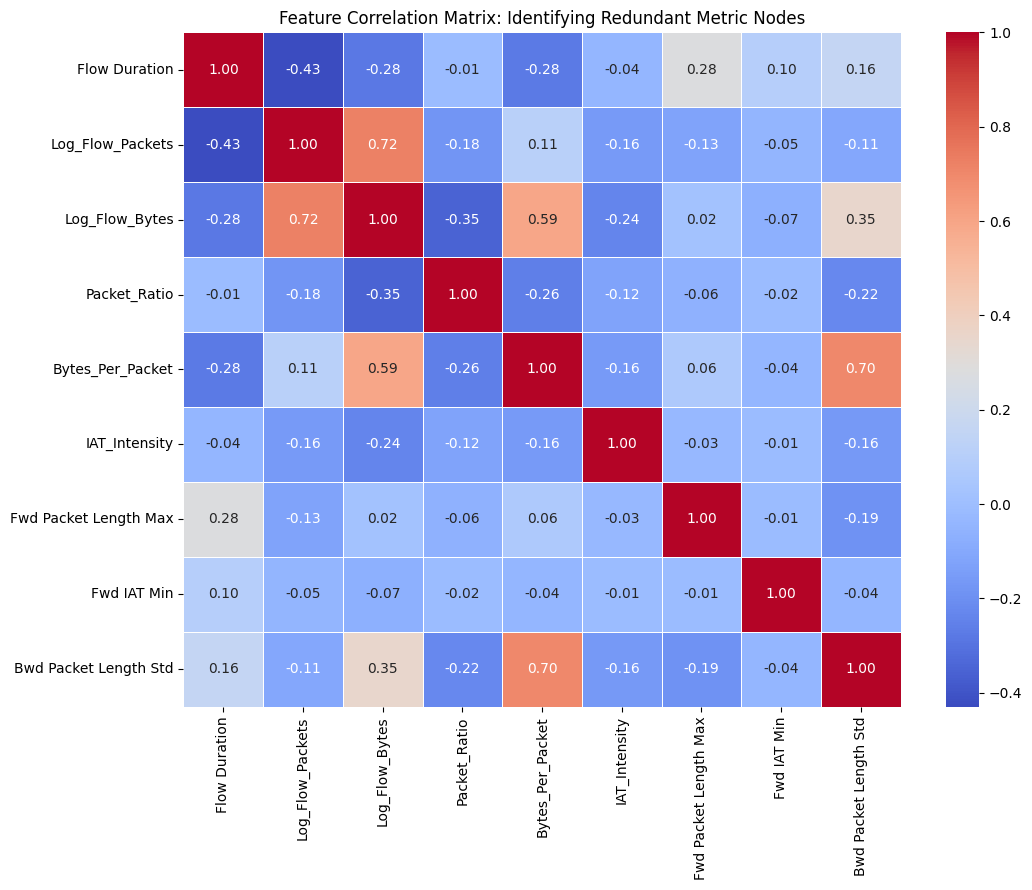

Features with zero variance detected (Safe to drop before ML training): ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Pipeline complete! The workspace dataset is ready for Machine Learning split scaling.


In [17]:
print("\nStep 8: Generating correlation matrix to flag redundant features...")

# Isolate a subset of core features to keep the heatmap clear and readable
core_features = [
    'Flow Duration', 'Log_Flow_Packets', 'Log_Flow_Bytes', 
    'Packet_Ratio', 'Bytes_Per_Packet', 'IAT_Intensity',
    'Fwd Packet Length Max', 'Fwd IAT Min', 'Bwd Packet Length Std'
]

plt.figure(figsize=(11, 9))
corr_matrix = DDOS[core_features].corr()

# Render heat map
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix: Identifying Redundant Metric Nodes')
plt.tight_layout()
plt.show()

# Print out any columns that provide zero informational variance
zero_variance_cols = [col for col in DDOS.columns if DDOS[col].nunique() == 1]
print(f"Features with zero variance detected (Safe to drop before ML training): {zero_variance_cols}")
print("\nPipeline complete! The workspace dataset is ready for Machine Learning split scaling.")